# Modelos clásicos de series temporales: Prophet y SARIMAX

**TFM — Forecasting de demanda eléctrica peninsular horaria**

Este notebook presenta los dos modelos clásicos del proyecto, cada uno con sus
resultados, y termina comparándolos. No entrena nada: consume los CSV que generan los
scripts de `src/models/`.

| | |
|---|---|
| **Horizonte** | 72 h (3 días) — la comercializadora compra en OMIE a 3 días vista |
| **Validación** | Walk-forward: ventanas mensuales de test (may 2025 → mar 2026) |
| **Entrenamiento** | Expanding: todo el histórico (2021 →) hasta cada fecha de corte |
| **Métrica principal** | MAPE (%) |
| **Objetivo del TFM** | MAPE < 3 % |

**Índice**
1. [Prophet](#1.-Prophet)
2. [SARIMAX](#2.-SARIMAX)
3. [Comparativa](#3.-Comparativa-Prophet-vs-SARIMAX)

| Script | Salida que usa este notebook |
|---|---|
| `src/models/prophet_walkforward.py` | `reports/walkforward_resultados.csv` |
| `src/models/prophet_rolling.py` | `reports/rolling_resultados.csv` |
| `src/models/sarimax_armonico.py` | `reports/sarimax_validacion.csv`, `sarimax_resultados.csv` |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"

# Paleta validada para daltonismo: azul = Prophet, verde-agua = SARIMAX.
C_PROPHET, C_SARIMAX = "#2a78d6", "#1baf7a"
C_INK, C_MUTED, C_GRID = "#101116", "#8b8e98", "#e5e6ec"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C_GRID, "axes.labelcolor": C_INK,
    "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": C_INK, "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "font.size": 10,
})
OBJETIVO = 3.0  # MAPE objetivo del TFM (%)


def grafica_ventanas(piv, series, titulo):
    '''Línea de MAPE por ventana. series = [(columna, color, etiqueta), ...]'''
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for col, color, etiqueta in series:
        ax.plot(piv.index, piv[col], marker="o", ms=6, lw=2, color=color,
                markeredgecolor="white", markeredgewidth=1.5,
                label=f"{etiqueta}  (media {piv[col].mean():.2f} %)")
    ax.axhline(OBJETIVO, ls="--", lw=1.5, color=C_MUTED, zorder=0)
    ax.text(piv.index[-1], OBJETIVO, "  objetivo TFM (3 %)", va="center",
            ha="left", color=C_MUTED, fontsize=9)
    ax.set_ylim(0, 12)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_ylabel("MAPE")
    ax.set_xlabel("Ventana de validación (fecha de corte)")
    ax.set_title(titulo, loc="left", pad=12)
    ax.grid(axis="y", lw=1)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


def test_pareado(piv, a, b):
    '''Test de Wilcoxon pareado ventana a ventana. Positivo en dif = gana b.'''
    d = piv[a] - piv[b]
    p = stats.wilcoxon(piv[a], piv[b]).pvalue
    gana = b if d.mean() > 0 else a
    n = int(max((d > 0).sum(), (d < 0).sum()))
    v = "SIGNIFICATIVO" if p < 0.05 else "no significativo"
    print(f"{a}  vs  {b}:")
    print(f"   dif media {d.mean():+.2f} pp | gana {gana} en {n}/{len(d)} ventanas "
          f"| Wilcoxon p = {p:.4f} -> {v}")

---
## 1. Prophet

**Qué es.** Modelo aditivo de Facebook/Meta pensado para series con estacionalidades
fuertes. Descompone la serie en tendencia + estacionalidades (diaria, semanal y anual,
construidas con senos y cosenos) + efecto de festivos, y admite variables externas
(regresores). Aquí se usa en modo **multiplicativo**: la amplitud del ciclo diario crece
con el nivel de demanda (los picos de invierno son más grandes en MW que los de un
abril suave).

**Dos variantes evaluadas:**
- **baseline** — calendario + festivos (`holidays.Spain`), sin clima.
- **clima** — añade como regresores: HDD, CDD, humedad relativa, viento y radiación
  solar. *(HDD/CDD = grados de calefacción/refrigeración: cuánto frío o calor hace
  respecto a una temperatura de confort — capturan la forma de U de la demanda frente
  a la temperatura.)*

In [2]:
wf = pd.read_csv(REPORTS / "walkforward_resultados.csv", parse_dates=["cutoff"])
piv_p = wf.pivot(index="cutoff", columns="modelo", values="MAPE_%")

resumen_p = (wf.groupby("modelo")
               .agg(MAPE_medio=("MAPE_%", "mean"), Desviación=("MAPE_%", "std"),
                    Peor_ventana=("MAPE_%", "max"), MAE_MW=("MAE_MW", "mean"))
               .round(2).sort_values("MAPE_medio"))
print(f"Ventanas evaluadas: {piv_p.shape[0]}")
resumen_p

Ventanas evaluadas: 11


,MAPE_medio,Desviación,Peor_ventana,MAE_MW
modelo,,,,
clima,5.51,1.96,8.96,1287.91
baseline,6.07,2.03,9.62,1442.75


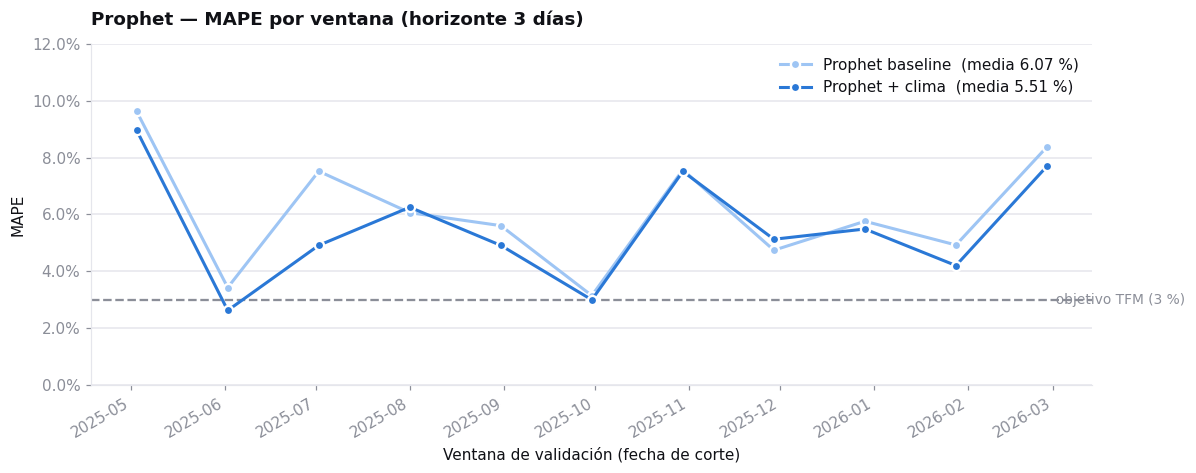

In [3]:
grafica_ventanas(
    piv_p,
    [("baseline", "#9ec5f4", "Prophet baseline"),
     ("clima",    C_PROPHET, "Prophet + clima")],
    "Prophet — MAPE por ventana (horizonte 3 días)",
)

In [4]:
# ¿La mejora del clima es real o es ruido? Test pareado ventana a ventana.
test_pareado(piv_p, "baseline", "clima")

baseline  vs  clima:
   dif media +0.55 pp | gana clima en 9/11 ventanas | Wilcoxon p = 0.0244 -> SIGNIFICATIVO


**Lectura.** El clima mejora a Prophet en ~0,55 puntos de MAPE, gana en 9 de 11
ventanas y la mejora es **estadísticamente significativa** (p = 0,024). Es un efecto
físico esperable: la temperatura mueve calefacción y aire acondicionado, que son una
parte importante de la demanda.

### 1.1 ¿Cuánto histórico conviene usar? (rolling vs expanding)

Parte del reparto de validación del grupo. Pregunta: ¿es mejor entrenar con TODO el
histórico (expanding) o solo con lo reciente (rolling)? Si la demanda hubiera cambiado
de régimen (post-COVID, autoconsumo…), el pasado lejano estorbaría.

In [5]:
roll = pd.read_csv(REPORTS / "rolling_resultados.csv", parse_dates=["cutoff"])
piv_r = roll.pivot(index="cutoff", columns="estrategia", values="MAPE_%")

print(piv_r.mean().round(2).rename("MAPE medio (%)").to_frame().to_string(), "\n")
for b in ["rolling 365d", "rolling 730d"]:
    test_pareado(piv_r, "expanding", b)

              MAPE medio (%)
estrategia                  
expanding               5.51
rolling 365d            5.05
rolling 730d            5.31 

expanding  vs  rolling 365d:
   dif media +0.47 pp | gana rolling 365d en 6/11 ventanas | Wilcoxon p = 0.5771 -> no significativo
expanding  vs  rolling 730d:
   dif media +0.20 pp | gana rolling 730d en 6/11 ventanas | Wilcoxon p = 0.8984 -> no significativo


**Lectura.** Ninguna diferencia es significativa: entrenar con 1 año, 2 o los 5
completos da lo mismo. **No hay deriva de régimen** en la demanda peninsular
2021–2026. Decisión: usar todo el histórico (expanding) — ante la igualdad, la opción
más defendible es no tirar datos.

---
## 2. SARIMAX

**Qué es.** El modelo clásico de series temporales (familia ARIMA) con variables
exógenas. Aquí no se usa el SARIMA "de libro" sino una **regresión armónica dinámica**,
que es el enfoque recomendado (Hyndman) cuando la serie tiene varias estacionalidades:

- La demanda tiene **tres ciclos** (diario 24 h, semanal 168 h, anual ~8.766 h), pero
  SARIMAX solo tiene una ranura estacional (el parámetro `m`) — y con `m` grande el
  coste computacional se dispara.
- Solución: los ciclos se sacan **fuera** del modelo como exógenas en forma de senos y
  cosenos (**términos de Fourier**) — el mismo truco que Prophet usa por dentro — y el
  término ARMA se queda solo con la autocorrelación de corto plazo de los residuos.

**Exógenas:** Fourier (diario K=8, semanal K=3, anual K=10) + festivos [+ clima en la
variante clima]. **Dos detalles de implementación que costaron caros** (documentados
para la memoria): statsmodels no incluye constante por defecto (`trend="c"` es
obligatorio) y las exógenas deben **estandarizarse** — sin ello el optimizador no
converge y devuelve un mal ajuste *sin avisar*.

### 2.1 Elección del orden ARMA

El orden (p,d,q) se eligió en un bloque de **validación** (may 2024 → mar 2025)
separado del test, para no contaminar la medida final:

In [6]:
pd.read_csv(REPORTS / "sarimax_validacion.csv").rename(
    columns={"order": "SARIMAX(p,d,q)", "MAPE_val_%": "MAPE en validación (%)"})

,"SARIMAX(p,d,q)",MAPE en validación (%)
0,"(2, 0, 0)",4.20
1,"(2, 0, 2)",4.20
2,"(1, 0, 0)",4.21
3,"(3, 0, 1)",4.24


Todos los órdenes rinden prácticamente igual (4,20–4,24 %): a 72 horas vista la memoria
del término ARMA se agota mucho antes del final del horizonte, así que da igual cuánta
se le ponga. Se elige **(2,0,0)** por parsimonia.

### 2.2 Resultados

In [7]:
sx = pd.read_csv(REPORTS / "sarimax_resultados.csv", parse_dates=["cutoff"])
piv_s = sx.pivot(index="cutoff", columns="modelo", values="MAPE_%")

resumen_s = (sx.groupby("modelo")
               .agg(MAPE_medio=("MAPE_%", "mean"), Desviación=("MAPE_%", "std"),
                    Peor_ventana=("MAPE_%", "max"), MAE_MW=("MAE_MW", "mean"))
               .round(2).sort_values("MAPE_medio"))
print(f"Ventanas evaluadas: {piv_s.shape[0]}")
if "converge" in sx.columns and not sx["converge"].all():
    print(f"Aviso: {(~sx['converge']).sum()} ajustes sin converger.")
resumen_s

Ventanas evaluadas: 12


,MAPE_medio,Desviación,Peor_ventana,MAE_MW
modelo,,,,
sarimax clima,5.38,1.81,9.01,1304.54
sarimax baseline,5.92,2.19,11.16,1456.40


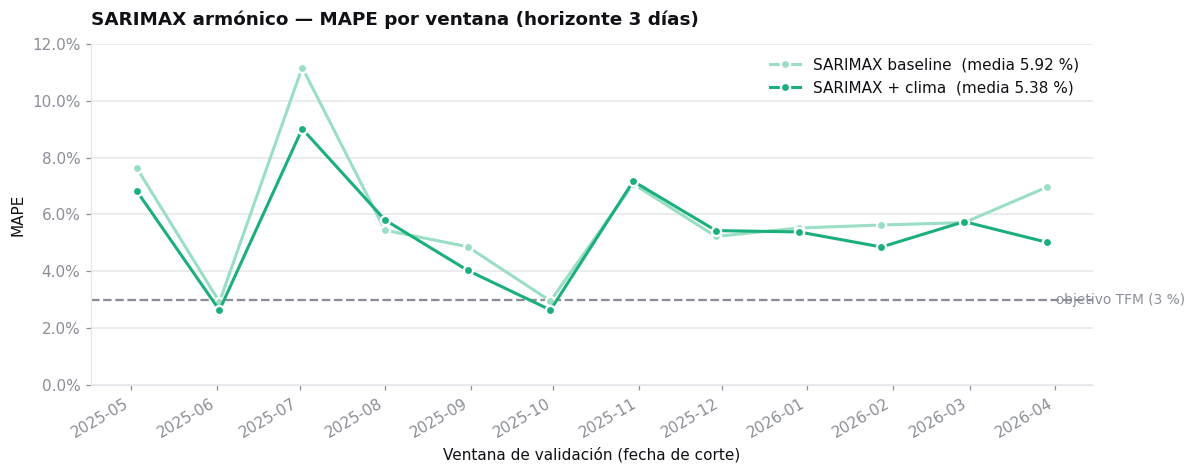

In [8]:
grafica_ventanas(
    piv_s,
    [("sarimax baseline", "#9adfc4", "SARIMAX baseline"),
     ("sarimax clima",    C_SARIMAX, "SARIMAX + clima")],
    "SARIMAX armónico — MAPE por ventana (horizonte 3 días)",
)

In [9]:
test_pareado(piv_s, "sarimax baseline", "sarimax clima")

sarimax baseline  vs  sarimax clima:
   dif media +0.55 pp | gana sarimax clima en 8/12 ventanas | Wilcoxon p = 0.0522 -> no significativo


**Lectura.** El clima mejora a SARIMAX en ~0,55 puntos — la misma magnitud que en
Prophet — y gana en 8 de 12 ventanas, pero se queda **justo al borde de la
significación** (p = 0,052). Con solo 12 ventanas, un efecto de este tamaño está en el
límite de lo detectable: la dirección y la magnitud coinciden con Prophet, pero este
test por sí solo no basta para afirmarlo.

---
## 3. Comparativa Prophet vs SARIMAX

Para comparar de tú a tú hay que usar **las mismas ventanas en ambos**. SARIMAX evaluó
12 y Prophet 11 (la ventana del 28-mar-2026 cae en el cambio de hora: ese día tiene 23
horas y el test de Prophet quedó incompleto). Ventanas comunes: **11**.

In [10]:
piv_c = pd.concat(
    [piv_p.rename(columns={"baseline": "Prophet baseline",
                           "clima": "Prophet clima"}),
     piv_s.rename(columns={"sarimax baseline": "SARIMAX baseline",
                           "sarimax clima": "SARIMAX clima"})],
    axis=1,
).dropna()

ORDEN = ["SARIMAX clima", "Prophet clima", "SARIMAX baseline", "Prophet baseline"]
piv_c = piv_c[ORDEN]

print(f"Ventanas comunes: {len(piv_c)}\n")
(piv_c.agg(["mean", "std", "max"]).T
      .rename(columns={"mean": "MAPE_medio_%", "std": "Desviación",
                       "max": "Peor_ventana_%"})
      .round(2).sort_values("MAPE_medio_%"))

Ventanas comunes: 11



,MAPE_medio_%,Desviación,Peor_ventana_%
modelo,,,
SARIMAX clima,5.41,1.90,9.01
Prophet clima,5.51,1.96,8.96
SARIMAX baseline,5.83,2.27,11.16
Prophet baseline,6.07,2.03,9.62


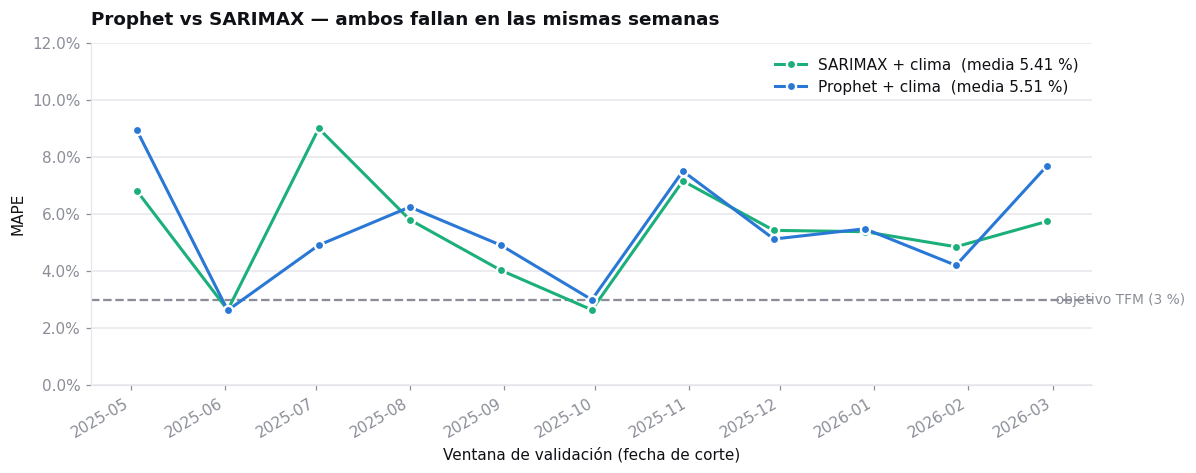

In [11]:
grafica_ventanas(
    piv_c,
    [("SARIMAX clima", C_SARIMAX, "SARIMAX + clima"),
     ("Prophet clima", C_PROPHET, "Prophet + clima")],
    "Prophet vs SARIMAX — ambos fallan en las mismas semanas",
)

In [12]:
test_pareado(piv_c, "Prophet clima", "SARIMAX clima")
test_pareado(piv_c, "Prophet baseline", "SARIMAX baseline")

r = piv_c["Prophet clima"].corr(piv_c["SARIMAX clima"])
print(f"\nCorrelación entre los errores de ambos modelos: r = {r:.2f}")

Prophet clima  vs  SARIMAX clima:
   dif media +0.10 pp | gana SARIMAX clima en 7/11 ventanas | Wilcoxon p = 0.3652 -> no significativo
Prophet baseline  vs  SARIMAX baseline:
   dif media +0.24 pp | gana SARIMAX baseline en 8/11 ventanas | Wilcoxon p = 0.3203 -> no significativo

Correlación entre los errores de ambos modelos: r = 0.64


### 3.1 Conclusiones

**Empate técnico.** La diferencia entre Prophet y SARIMAX es de 0,10 puntos con
p = 0,37: con estos datos **no se puede afirmar que uno sea mejor que el otro**. Y no
es casualidad — por debajo de la notación, ambos son esencialmente el mismo modelo:

| | Prophet | SARIMAX armónico |
|---|---|---|
| Ciclos diario/semanal/anual | estacionalidades (Fourier interno) | regresores de Fourier |
| Clima | `add_regressor` | variables exógenas |
| Tendencia | flexible (puntos de cambio) | constante |
| Residuos | ruido | ARMA(2,0) |

Lo único que los distingue de verdad (el término ARMA) no aporta a 72 h (§2.1). De ahí
el empate: **la misma regresión armónica con clima, escrita en dos notaciones**.

**El techo del ~5,4 %.** Ninguno baja de ahí, lejos del objetivo del 3 %. Sus errores
además están correlacionados (r = 0,64): en buena medida fallan ante lo mismo. La
interpretación: es el límite de lo predecible sabiendo solo *qué día es* y *qué tiempo
hará*, sin usar el consumo reciente. Los retardos de demanda del dataset
(`demanda_lag_24h`, `demanda_lag_168h`) son exactamente la información que estos
modelos no explotan y que queda para el modelo de gradient boosting (LightGBM).

### 3.2 Resumen ejecutivo del bloque

| Hipótesis | Resultado | p |
|---|---|---|
| Añadir clima mejora la predicción | **Sí** en Prophet; misma magnitud en SARIMAX, al borde de la significación | 0,024 / 0,052 |
| Algún modelo es mejor que el otro | **No** — equivalentes | 0,37 |
| Acortar la ventana de entrenamiento mejora | **No** — no hay deriva de régimen | 0,58 |
| Subir el orden ARMA mejora | **No** — la memoria no llega a 72 h | — |

### 3.3 Notas metodológicas

- **Un holdout único no es fiable**: varias veces durante el trabajo, un holdout suelto
  de 3 días apuntó a conclusiones que el walk-forward desmintió. Todos los números de
  este notebook son medias sobre 11–12 ventanas con test pareado de Wilcoxon.
- **El clima del test es el observado**, no una previsión — equivale a asumir
  "previsión meteorológica perfecta". A 3 días la previsión real es muy buena, así que
  la degradación esperable en producción es pequeña.
- **Abril de 2026 está excluido** (dato provisional de Esios, caída del 40 % imposible);
  el estudio termina el 31-mar-2026. **El apagón ibérico** del 28-abr-2025 (36 h) se
  imputó por semana análoga (±7 días).